In [26]:
from dotenv import load_dotenv
load_dotenv()

True

In [35]:
from langgraph.graph import START,END,StateGraph
from pydantic import BaseModel,Field
from langchain_groq import  ChatGroq
from langgraph.types import interrupt,Command
from typing import Literal
from langgraph.checkpoint.memory import InMemorySaver

In [28]:
class StateFlow(BaseModel):
    query:str=""
    draft:str=""
    human_feedback:str=""
    final_response:str=""



In [29]:
llm=ChatGroq(model="Openai/gpt-oss-20b")

In [30]:
def DraftNode(state:StateFlow):
    prompt = f"""
    Original request:
    {state.query}

    Previous draft:
    {state.draft}

    Human feedback:
    {state.human_feedback}

    Create or rewrite the email based on the information above.
    """
    res=llm.invoke(prompt).content
    state.draft=res
    return state

def HumanFeedbackNode(state:StateFlow):
    feedback=interrupt({
        "Draft-mail":state.draft,
        "Question":"Do you want to continue or rewrite the mail..?"
    })

    fb=(feedback or "").strip().lower()
    if fb in ['yes','approved','ok']:
        state.human_feedback=""
        return state
    else:
        state.human_feedback=feedback
        return state
    
def FinializeNode(state:StateFlow):
        if state.human_feedback:
            state.final_response=state.human_feedback
            return state
        else:
            state.final_response="Email Sent.."
            return state
    
def Conditional_routing(state:StateFlow)->Literal["Draft","Final"]:
    if state.human_feedback:
        return "Draft"
    else:
        return "Final"

    

In [31]:
graph_builder=StateGraph(StateFlow)
graph_builder.add_node("Draft",DraftNode)
graph_builder.add_node("HumanFeedback",HumanFeedbackNode)
graph_builder.add_node("Final",FinializeNode)

graph_builder.add_edge(START,"Draft")
graph_builder.add_edge("Draft","HumanFeedback")
graph_builder.add_conditional_edges("HumanFeedback",Conditional_routing)
graph_builder.add_edge("Final",END)


In [38]:
graph=graph_builder.compile(checkpointer=InMemorySaver())

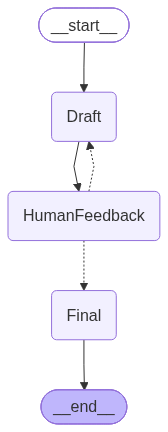

In [39]:
from IPython.display import Image, display

display(Image(graph.get_graph().draw_mermaid_png()))

In [44]:
config = {
    "configurable": {
        "thread_id": "email-1"
    }
}

result = graph.invoke(
    {
        "query": "Write an email to my professor asking for an assignment extension."
    },
    config=config
)



In [45]:
print(result["draft"])

**Subject:** Request for a Brief Extension on [Assignment Title]

Dear Professor [Last Name],

I hope you are doing well. I am writing to respectfully request a short extension for the [assignment title], which is currently due on [original due date].

Over the past week I have been dealing with [brief explanation – e.g., “a sudden illness” or “an urgent family matter”], which has limited the time I can devote to the assignment. I want to submit work that reflects my best effort and meets the course’s standards, so I would greatly appreciate an additional [number of days, e.g., “3 days”] to complete it.

If granted, I propose a new submission date of [new due date]. I will ensure the assignment is finished and submitted by that time and will keep you updated on any further developments.

Thank you very much for your understanding and consideration.

Warm regards,

[Your Full Name]  
[Course Title & Section]  
[Student ID]  
[Email Address]  
[Phone Number]


In [ ]:
result = graph.invoke(
    Command(resume="Make the email more professional and concise."),
    config=config
)



{'query': 'Write an email to my professor asking for an assignment extension.', 'draft': '**Subject:** Request for Extension on [Assignment Title]\n\nDear Professor\u202f[Last Name],\n\nI hope you are well. I am writing to request a brief extension for the [assignment title], originally due on [original due date]. Due to [brief reason—e.g., a sudden illness or urgent family matter], I have been unable to devote the necessary time to complete the work to my usual standard.\n\nI respectfully ask for an additional [number of days] days, with a new submission date of [new due date]. I will ensure the assignment is submitted by that time and will keep you informed of any changes.\n\nThank you for your consideration.\n\nSincerely,\n\n[Your Full Name]  \n[Course Title & Section]  \nStudent ID: [Student ID]  \nEmail: [Email Address]  \nPhone: [Phone Number]', 'human_feedback': 'Make the email more professional and concise.', 'final_response': '', '__interrupt__': [Interrupt(value={'Draft-mail'

In [47]:
print(result['draft'])

**Subject:** Request for Extension on [Assignment Title]

Dear Professor [Last Name],

I hope you are well. I am writing to request a brief extension for the [assignment title], originally due on [original due date]. Due to [brief reason—e.g., a sudden illness or urgent family matter], I have been unable to devote the necessary time to complete the work to my usual standard.

I respectfully ask for an additional [number of days] days, with a new submission date of [new due date]. I will ensure the assignment is submitted by that time and will keep you informed of any changes.

Thank you for your consideration.

Sincerely,

[Your Full Name]  
[Course Title & Section]  
Student ID: [Student ID]  
Email: [Email Address]  
Phone: [Phone Number]


In [48]:
result = graph.invoke(
    Command(resume="approved"),
    config=config
)

In [50]:
print(result['final_response'])

Email Sent..
